In [27]:
from platosim.simfile import SimFile
from platosim.simulation import Simulation
from platosim.validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import ConnectionPatch
import scipy.stats as stats

In [28]:
sim = Simulation("Flatfielding")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

In [29]:
# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Enable flatfielding

sim["CCD/IncludeFlatfield"] = "yes"
rms = sim["CCD/FlatfieldNoiseRMS"]

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

sim["ControlHDF5Content/WriteSubPixelImages"] = "true"

output = sim.run(removeOutputFile = True)

image = output.getImage(0)


2022-07-19 14:52:24 WARNING Simulation: no information about detected stars to write to HDF5
2022-07-19 14:52:26 WARNING Camera: No star positions to write to HDF5 file.



# PRNU derived directly from the image

In [30]:
mean = np.mean(image)
prnuFromImage = math.sqrt(np.mean((image - mean)**2)) / mean

print("PRNU derived from PlatoSim output:", prnuFromImage)
print("To compare with input value in the configuration file:", rms)

PRNU derived from PlatoSim output: 0.010100903127662224
To compare with input value in the configuration file: 0.01


# Flatfield map

In [31]:
flatfield = output.getPRNU()

## Histogram

(0.97, 1.03)

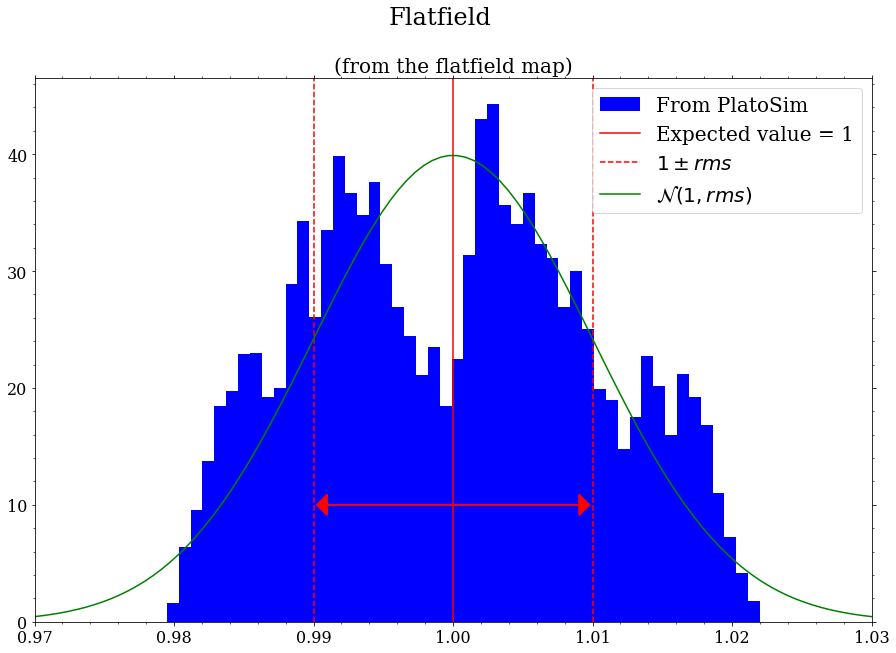

In [32]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

###############
# From PlatoSim
###############

plt.hist(np.ravel(flatfield), 50, density = True, color = "b", label = "From PlatoSim")

#################
# Expected values
#################

plt.axvline(x = 1, color = "r", label = "Expected value = 1")
plt.axvline(x = 1 - rms, color ="r", linestyle = "dashed", label = "$1 \\pm rms$")
plt.axvline(x = 1 + rms, color = "r", linestyle = "dashed")
ax.annotate("",
            xy=(1 - rms, 10), xycoords='data',
            xytext=(1 + rms, 10), textcoords='data',
            arrowprops=dict(arrowstyle="<|-|>, head_width = 1, head_length = 1",
                            connectionstyle="arc3", color="r", lw="2")
            )

mu = 1
sigma = rms
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), "g", label="$\mathcal{N}(1, rms)$")

########
# Layout
########

plt.suptitle("Flatfield", fontsize = 24)
plt.title("(from the flatfield map)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([0.97, 1.03])

## Mean & standard deviation

In [33]:
meanFromFlatfieldMap = np.mean(flatfield)
stdDevFromFlatfieldMap = np.std(flatfield)

print("Mean from flatfield map:", meanFromFlatfieldMap)
print("To compare with expected value:", 1, "\n")

print("Standard deviation from flatfield map:", stdDevFromFlatfieldMap)
print("To compare with input value in the configuration file:", rms)

Mean from flatfield map: 0.99998534
To compare with expected value: 1 

Standard deviation from flatfield map: 0.010100761
To compare with input value in the configuration file: 0.01


## 1 / f dependency

In [34]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def func(x, a):
    
    return a / x

In [35]:
fft = np.fft.fft2(flatfield)
realPart = np.abs(fft)

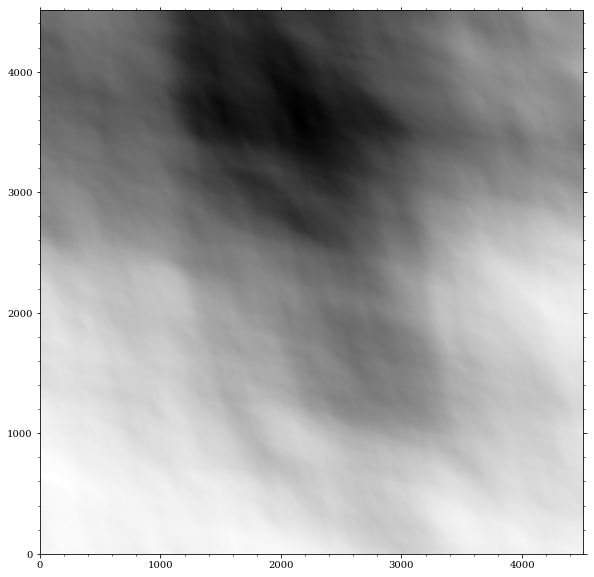

In [38]:
plt.figure(figsize=(10,10))
plt.imshow(flatfield, origin='lower', cmap='Greys')
plt.show()

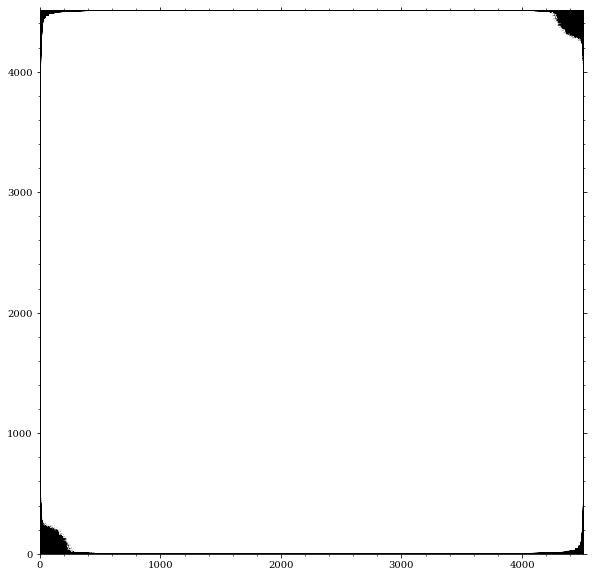

In [41]:
plt.figure(figsize=(10,10))
im = plt.imshow(realPart, origin='lower', cmap='Greys', vmin=1, vmax=1.2)
plt.show()

/tmp/ipykernel_411909/3172817338.py:6: RuntimeWarning: divide by zero encountered in true_divide
  return a / x


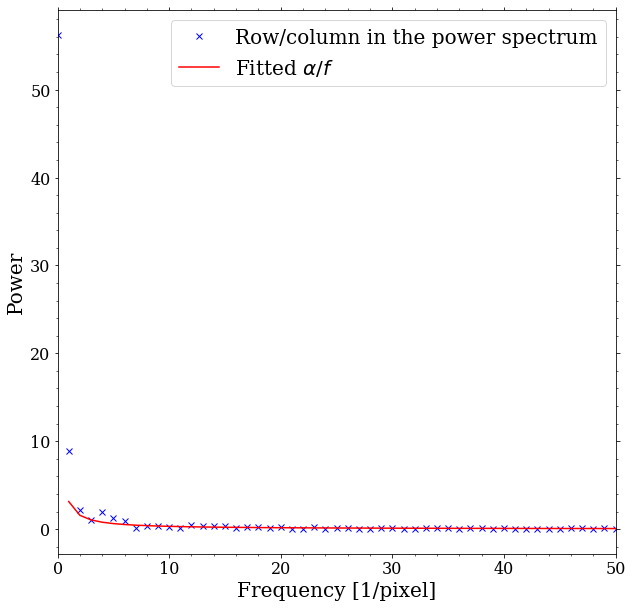

In [42]:
y = realPart[:][2000]
popt, pcov = curve_fit(func, np.arange(10,100), y[10:100])
    
fig = plt.figure(figsize = (10, 10))

ax = fig.add_subplot(1, 1, 1)
curve_fit(func, np.arange(10,100), y[10:100])

plt.plot(y, "bx", label="Row/column in the power spectrum")
plt.plot(func(np.arange(0,100), *popt), "r", label="Fitted $\\alpha /f$")

########
# Layout
########

# plt.title("Cosmic hits", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

plt.xlim([0,50])
# plt.ylim([0,0.5])

plt.xlabel("Frequency [1/pixel]", fontsize = 20)
plt.ylabel("Power", fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)


/tmp/ipykernel_411909/2261103090.py:7: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(r, 1 / r, "r", linewidth=2, label="1/f")


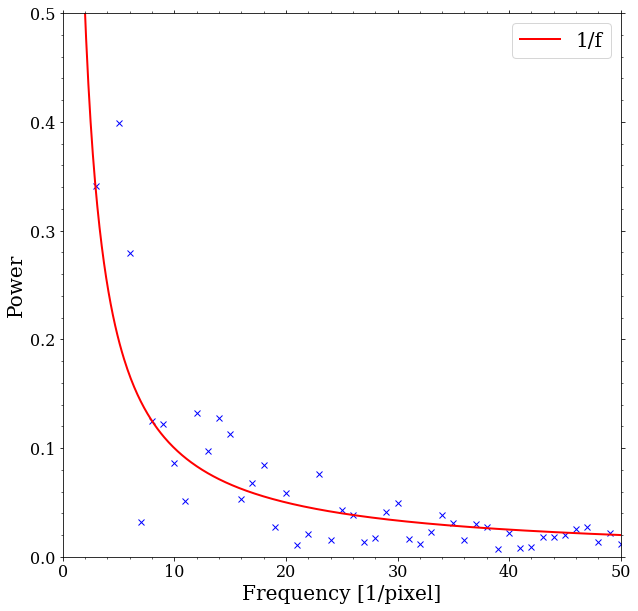

In [43]:
fig = plt.figure(figsize = (10, 10))

ax = fig.add_subplot(1, 1, 1)

plt.plot(y / popt[0], "bx")
r = np.arange(0,100, 0.1)
plt.plot(r, 1 / r, "r", linewidth=2, label="1/f")

########
# Layout
########

# plt.title("Cosmic hits", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

plt.xlim([0,50])
plt.ylim([0,0.5])

plt.xlabel("Frequency [1/pixel]", fontsize = 20)
plt.ylabel("Power", fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)


/tmp/ipykernel_411909/4240217399.py:15: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(r, 1 / r, "k", linewidth=2, label="1/f")
/tmp/ipykernel_411909/4240217399.py:43: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(r, (1 / r), "k", linewidth=2, label="1/f")


Text(0.5, 0.98, 'Flatfield (from the flatfield map)')

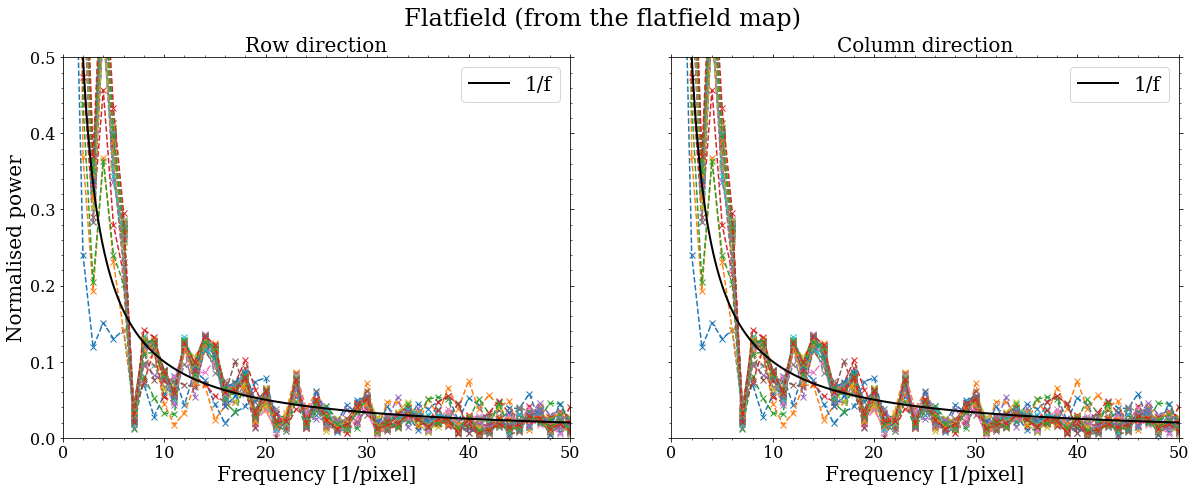

In [44]:
fig = plt.figure(figsize = (20, 7))
plt.tight_layout()

ax1 = fig.add_subplot(1, 2, 1)

for row in range(100, 4500, 100):
    
    y = realPart[row]
    popt, pcov = curve_fit(func, np.arange(10,100), y[10:100])
    
    plt.plot(y / popt[0], marker="x", linestyle="--") 
    
    
r = np.arange(0,5000, 0.1)
plt.plot(r, 1 / r, "k", linewidth=2, label="1/f")

plt.xlabel("Frequency [1/pixel]", fontsize = 20)
plt.ylabel("Normalised power", fontsize = 20)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,50])
plt.ylim([0,0.5])


plt.title("Row direction", fontsize = 20)
plt.legend(loc='best', fontsize = 20)


ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

for column in range(100, 4500, 100):
    
    y = realPart[:][column]
    popt, pcov = curve_fit(func, np.arange(10,100), y[10:100])
    
    plt.plot(y / popt[0], marker="x", linestyle="--") 
    
plt.plot(r, (1 / r), "k", linewidth=2, label="1/f")

plt.xlabel("Frequency [1/pixel]", fontsize = 20)

for tick in ax2.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax2.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
plt.setp(ax2.get_yticklabels(), visible=False)

plt.xlim([0,50])
plt.ylim([0,0.5])

plt.title("Column direction", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

fig.suptitle("Flatfield (from the flatfield map)", fontsize=24)

In [ ]:
# fig = plt.figure(figsize = (15, 10))
# plt.tight_layout()

# ax1 = fig.add_subplot(1, 2, 1)

# for row in range(100, 4500, 100):
    
#     plt.plot(realPart[row] / realPart[row, 25], marker="x", linestyle="--")
    
#     y = realPart[row]
#     popt, pcov = curve_fit(func, np.arange(1,len(y) + 1), y)
    
# r = np.arange(0,1500, 0.1)
# plt.plot(r, 25 / r, "k", linewidth=2, label="1/f")

# plt.xlabel("Frequency [1/pixel]", fontsize = 20)
# plt.ylabel("Normalised power", fontsize = 20)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# for tick in ax1.yaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# plt.xlim([0,50])
# plt.ylim([-1,50])
# # plt.ylim([0,1.25])

# plt.title("Row direction", fontsize = 20)
# plt.legend(loc='best', fontsize = 20)


# ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

# for column in range(100, 4500, 100):
    
#     plt.plot(realPart[:][column] / realPart[:][column][25], marker="x", linestyle="--")
    
# plt.plot(r, (25 / r), "k", linewidth=2, label="1/f")

# plt.xlabel("Frequency [1/pixel]", fontsize = 20)

# for tick in ax2.xaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# for tick in ax2.yaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
# plt.setp(ax2.get_yticklabels(), visible=False)

# plt.xlim([0,50])
# plt.ylim([-1,50])
# # plt.ylim([0,1.25])

# plt.title("Column direction", fontsize = 20)
# plt.legend(loc='best', fontsize = 20)

# fig.suptitle("Flatfield (from the flatfield map)", fontsize=24)

# Comparison

In [45]:
image = output.getImage(0)

sim["CCD/IncludeFlatfield"] = "no"
output = sim.run(removeOutputFile = True)
refImage = output.getImage(0)


2022-07-19 14:55:27 WARNING Simulation: no information about detected stars to write to HDF5
2022-07-19 14:55:29 WARNING Camera: No star positions to write to HDF5 file.



In [46]:
quotient = image / refImage

(0.97, 1.03)

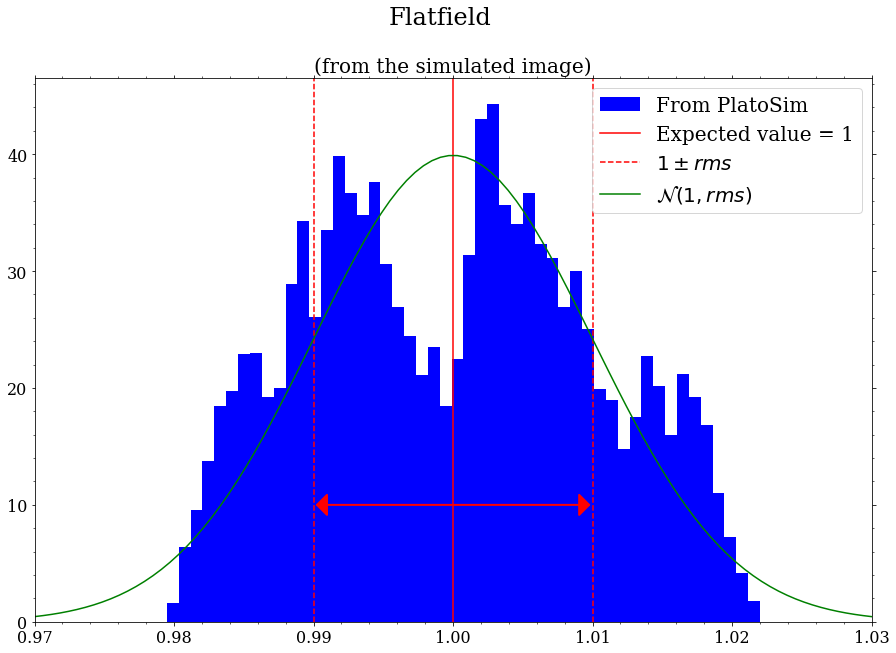

In [48]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

###############
# From PlatoSim
###############

plt.hist(np.ravel(quotient), 50, density = True, color = "b", label = "From PlatoSim")

#################
# Expected values
#################

plt.axvline(x = 1, color = "r", label = "Expected value = 1")
plt.axvline(x = 1 - rms, color ="r", linestyle = "dashed", label = "$1 \\pm rms$")
plt.axvline(x = 1 + rms, color = "r", linestyle = "dashed")
ax.annotate("",
            xy=(1 - rms, 10), xycoords='data',
            xytext=(1 + rms, 10), textcoords='data',
            arrowprops=dict(arrowstyle="<|-|>, head_width = 1, head_length = 1",
                            connectionstyle="arc3", color="r", lw="2")
            )

mu = 1
sigma = rms
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), "g", label="$\mathcal{N}(1, rms)$")

########
# Layout
########

plt.suptitle("Flatfield", fontsize = 24)
plt.title("(from the simulated image)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0.97, 1.03])

In [49]:
meanFromQuotientMap = np.mean(quotient)
stdDevFromQuotientMap = np.std(quotient)

print("Mean from quotient map:", meanFromQuotientMap)
print("To compare with expected value:", 1, "\n")

print("Standard deviation from quotient map:", stdDevFromQuotientMap)
print("To compare with input value in the configuration file:", rms)

Mean from quotient map: 0.99998534
To compare with expected value: 1 

Standard deviation from quotient map: 0.010100761
To compare with input value in the configuration file: 0.01


## 1/f dependency

In [50]:
fft = np.fft.fft2(quotient)
realPart = np.abs(fft)

/tmp/ipykernel_411909/2066110180.py:15: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(r, 1 / r, "k", linewidth=2, label="1/f")
/tmp/ipykernel_411909/2066110180.py:43: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(r, (1 / r), "k", linewidth=2, label="1/f")


Text(0.5, 0.98, 'Flatfield (from the simulated image)')

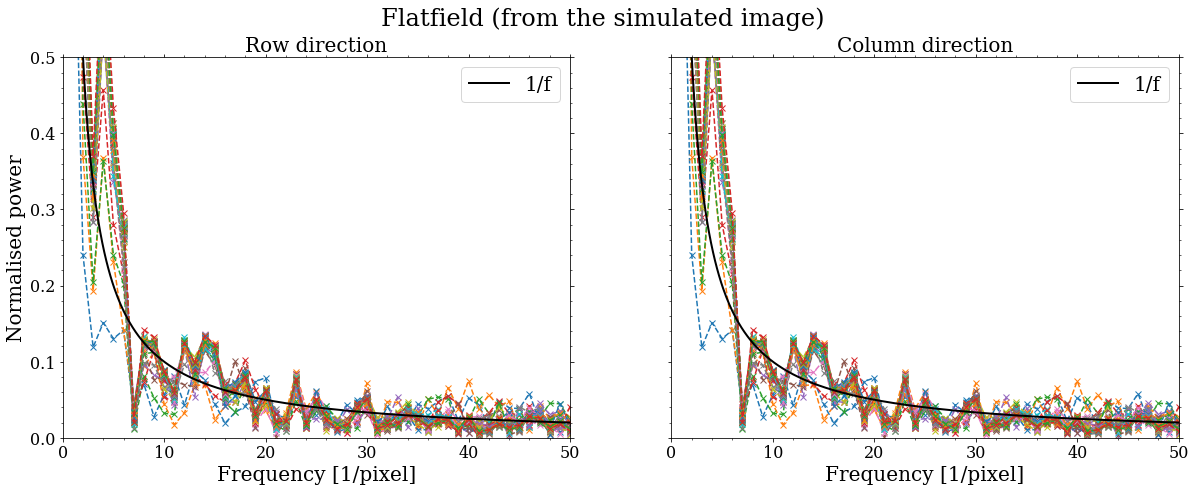

In [51]:
fig = plt.figure(figsize = (20, 7))
plt.tight_layout()

ax1 = fig.add_subplot(1, 2, 1)

for row in range(100, 4500, 100):
    
    y = realPart[row]
    popt, pcov = curve_fit(func, np.arange(10,100), y[10:100])
    
    plt.plot(y / popt[0], marker="x", linestyle="--") 
    
    
r = np.arange(0,5000, 0.1)
plt.plot(r, 1 / r, "k", linewidth=2, label="1/f")

plt.xlabel("Frequency [1/pixel]", fontsize = 20)
plt.ylabel("Normalised power", fontsize = 20)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,50])
plt.ylim([0,0.5])


plt.title("Row direction", fontsize = 20)
plt.legend(loc='best', fontsize = 20)


ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

for column in range(100, 4500, 100):
    
    y = realPart[:][column]
    popt, pcov = curve_fit(func, np.arange(10,100), y[10:100])
    
    plt.plot(y / popt[0], marker="x", linestyle="--") 
    
plt.plot(r, (1 / r), "k", linewidth=2, label="1/f")

plt.xlabel("Frequency [1/pixel]", fontsize = 20)

for tick in ax2.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax2.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
plt.setp(ax2.get_yticklabels(), visible=False)

plt.xlim([0,50])
plt.ylim([0,0.5])

plt.title("Column direction", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

fig.suptitle("Flatfield (from the simulated image)", fontsize=24)

In [ ]:
# fig = plt.figure(figsize = (15, 10))
# plt.tight_layout()

# ax1 = fig.add_subplot(1, 2, 1)

# for row in range(100, 4500, 100):
    
#     plt.plot(realPart[row] / realPart[row, 25], marker="x", linestyle="--")
    
# r = np.arange(0,1500, 0.1)
# plt.plot(r, 25 / r, "k", linewidth=2, label="1/f")

# plt.xlabel("Frequency [1/pixel]", fontsize = 20)
# plt.ylabel("Normalised power", fontsize = 20)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# for tick in ax1.yaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# plt.xlim([0,50])
# plt.ylim([-1,50])

# plt.title("Row direction", fontsize = 20)
# plt.legend(loc='best', fontsize = 20)


# ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

# for column in range(100, 4500, 100):
    
#     plt.plot(realPart[:][column] / realPart[:][column][25], marker="x", linestyle="--")
    
# plt.plot(r, 25 / r, "k", linewidth=2, label="1/f")

# plt.xlabel("Frequency [1/pixel]", fontsize = 20)

# for tick in ax2.xaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# for tick in ax2.yaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
# plt.setp(ax2.get_yticklabels(), visible=False)

# plt.xlim([0,50])
# plt.ylim([-1,50])

# plt.title("Column direction", fontsize = 20)
# plt.legend(loc='best', fontsize = 20)

# fig.suptitle("Flatfield (from the simulated image)", fontsize=24)